# Tutorial 7 — Does the process meet the specification?

## 1. Problem / context

The specification for **mean** plate thickness is $\mu=250$ µm. The file `sensor_thickness.csv` is a sample of plates from the current process. A sample mean near 250 µm does not automatically mean the process is on target, and a small $p$-value does not automatically mean the process is unusable.

Brooks Chapter 7 is the theory of hypotheses, $p$-values, errors, and one-sample tests. This tutorial is the Python and reporting layer.

The observational unit is one plate. We fix the hypotheses **before** looking at the test result.

## 2. What we will compute

Two-sided question (a shift in either direction matters):

$$
H_0:\mu=250\qquad\text{versus}\qquad H_1:\mu\neq 250.
$$

If the only engineering concern were “too thick”, the alternative would be $H_1:\mu>250$. That choice is a property of the question, not of which way the sample mean happens to fall.

The one-sample $t$ statistic is

$$
t=\frac{\bar x-250}{s/\sqrt n},\qquad \nu=n-1.
$$

The $p$-value is the probability, **conditional on $H_0$ and the model assumptions**, of a test statistic as extreme as the observed one, or more extreme, in the direction specified by $H_1$. It is not $P(H_0\mid\text{data})$ and not the probability that the result occurred “by chance”.

A two-sided test at level $\alpha=0.05$ rejects $H_0$ when 250 µm lies outside the 95% $t$ interval (duality).

For a proportion we use an **exact binomial test** when counts are small, and the **score** test (with a Wilson interval) when the large-sample setting is adequate. An exact test and a Wilson interval are not dual, so we do not mix them and claim exact test–interval duality.

## 3. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t, ttest_1samp, shapiro, binomtest, norm, probplot

candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())
x = pd.read_csv(DATA / "sensor_thickness.csv")["thickness_um"].to_numpy()

mu0 = 250.0
n = x.size
xbar = x.mean()
s = x.std(ddof=1)
se = s / np.sqrt(n)
print(f"n = {n}, mean = {xbar:.3f} µm, s = {s:.3f} µm, SE = {se:.3f} µm")
print(f"difference from 250 µm: {xbar - mu0:.3f} µm")


n = 180, mean = 250.830 µm, s = 4.809 µm, SE = 0.358 µm
difference from 250 µm: 0.830 µm


Compute $t$ by hand, then verify with `ttest_1samp`. Set `alternative=` explicitly.


In [2]:
t_obs = (xbar - mu0) / se
p_two = 2 * t.sf(np.abs(t_obs), df=n - 1)
ci = t.interval(0.95, df=n - 1, loc=xbar, scale=se)
res = ttest_1samp(x, popmean=mu0, alternative="two-sided")
print(f"manual t = {t_obs:.3f}, df = {n - 1}, p = {p_two:.4g}")
print("SciPy:      ", res)
print("95% t-interval for µ (µm):", tuple(np.round(ci, 3)))
print("250 µm inside the interval?", ci[0] <= mu0 <= ci[1])


manual t = 2.316, df = 179, p = 0.02167
SciPy:       TtestResult(statistic=np.float64(2.3164656779472375), pvalue=np.float64(0.021665582029369343), df=np.int64(179))
95% t-interval for µ (µm): (np.float64(250.123), np.float64(251.538))
250 µm inside the interval? False


The two-sided $p$-value as a tail probability under the null $t$ model:


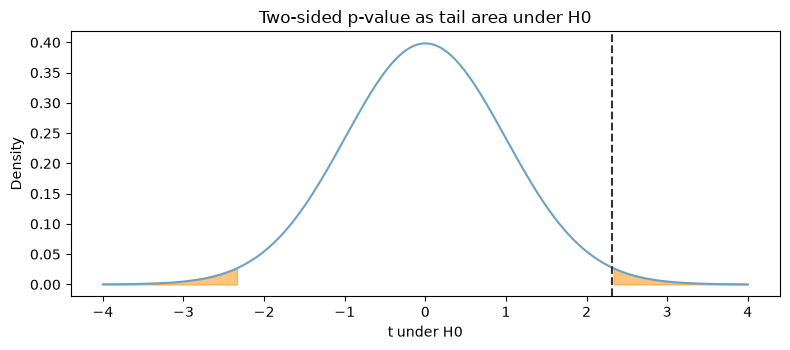

In [3]:
grid = np.linspace(-4, 4, 400)
pdf = t.pdf(grid, df=n - 1)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(grid, pdf, color="#6CA2C6")
ax.fill_between(grid, pdf, where=grid <= -abs(t_obs), color="#FF8C00", alpha=0.5)
ax.fill_between(grid, pdf, where=grid >= abs(t_obs), color="#FF8C00", alpha=0.5)
ax.axvline(t_obs, color="0.2", linestyle="--")
ax.set_xlabel("t under H0")
ax.set_ylabel("Density")
ax.set_title("Two-sided p-value as tail area under H0")
plt.tight_layout()
plt.show()


Pause: if $p$ is small, have we learned the **size** of the shift, or only that a shift of zero is hard to reconcile with this sample under the model?

### Assumption workflow

Independence and representative sampling are **design** questions. A histogram, QQ-plot, or Shapiro–Wilk test cannot establish them.


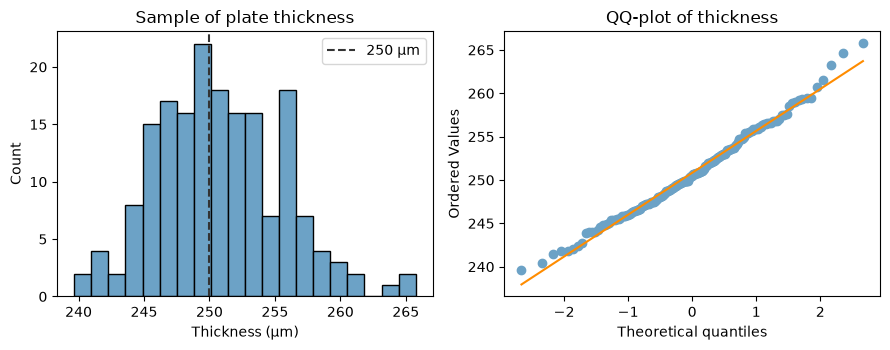

Shapiro–Wilk W = 0.990, p = 0.2513


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].hist(x, bins=20, color="#6CA2C6", edgecolor="black")
axes[0].axvline(mu0, color="0.2", linestyle="--", label="250 µm")
axes[0].set_xlabel("Thickness (µm)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sample of plate thickness")
axes[0].legend()
probplot(x, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_markerfacecolor("#6CA2C6")
axes[1].get_lines()[0].set_markeredgecolor("#6CA2C6")
axes[1].get_lines()[1].set_color("#FF8C00")
axes[1].set_title("QQ-plot of thickness")
plt.tight_layout()
plt.show()

W, p_sw = shapiro(x)
print(f"Shapiro–Wilk W = {W:.3f}, p = {p_sw:.4g}")


Shapiro–Wilk is supplementary. In a small sample it can miss a real departure; in a large sample it can flag an immaterial one. It does not test independence. We do not use a chi-square test of binned counts as a normality assessment.

### A one-sided alternative, chosen in advance

Suppose the only operational concern is that the process runs **thick**. Then, *before* seeing $\bar x$,

$$
H_0:\mu=250\qquad\text{versus}\qquad H_1:\mu>250.
$$


In [5]:
print(ttest_1samp(x, popmean=mu0, alternative="greater"))


TtestResult(statistic=np.float64(2.3164656779472375), pvalue=np.float64(0.010832791014684671), df=np.int64(179))


Do not switch from two-sided to one-sided after looking at the sign of $\bar x-250$.

### Type I error, type II error, and power (compact)

A type I error is rejecting a true $H_0$ (rate $\alpha$). A type II error is failing to reject a false $H_0$. Power is $1-\beta$.


In [6]:
rng = np.random.default_rng(2026)
n_rep, n_sim = 10_000, 30
sigma = 4.8

null_samples = rng.normal(250.0, sigma, size=(n_rep, n_sim))
alt_samples = rng.normal(252.0, sigma, size=(n_rep, n_sim))

def reject_rate(samples, mu0=250.0, alpha=0.05):
    means = samples.mean(axis=1)
    sds = samples.std(axis=1, ddof=1)
    tstat = (means - mu0) / (sds / np.sqrt(samples.shape[1]))
    p = 2 * t.sf(np.abs(tstat), df=samples.shape[1] - 1)
    return np.mean(p < alpha)

print("rejection rate when H0 is true (should be near α = 0.05):",
      reject_rate(null_samples))
print("rejection rate when mean is 252 µm (power at this n, shift, s):",
      reject_rate(alt_samples))


rejection rate when H0 is true (should be near α = 0.05): 0.0513
rejection rate when mean is 252 µm (power at this n, shift, s): 0.5981


This is not a full power-analysis chapter. It shows that “not significant” can mean “the study was too small for this shift”.

### One-sample proportion

Quality also tracks the proportion of plates thicker than 258 µm. The historical claim is $p=0.05$. Hypotheses, fixed in advance:

$$
H_0:p=0.05\qquad\text{versus}\qquad H_1:p\neq 0.05.
$$


In [7]:
k = int((x > 258).sum())
print(f"k = {k}, n = {n}, phat = {k / n:.4f}")
print("exact binomial test:", binomtest(k, n=n, p=0.05, alternative="two-sided"))

p0 = 0.05
z_score = (k / n - p0) / np.sqrt(p0 * (1 - p0) / n)
p_score = 2 * norm.sf(np.abs(z_score))
print(f"score statistic z = {z_score:.3f}, two-sided p ≈ {p_score:.4g}")
from statsmodels.stats.proportion import proportion_confint
print("Wilson 95% interval:", proportion_confint(k, n, method="wilson"))


k = 12, n = 180, phat = 0.0667
exact binomial test: BinomTestResult(k=12, n=180, alternative='two-sided', statistic=0.06666666666666667, pvalue=0.301492369653246)
score statistic z = 1.026, two-sided p ≈ 0.3049
Wilson 95% interval: (0.03854407493570258, 0.11289868992969537)


With $n=180$ the large-sample score test is a reasonable companion to a Wilson interval. The exact binomial $p$-value remains available because the count is discrete. Do not treat the exact test and the Wilson interval as dual: duality links a two-sided score test to a Wilson interval, not an exact binomial test to Wilson.

## 4. Interpretation

Report in the Chapter 7 order: population and parameter; hypotheses and direction; design and $n$; estimate and interval; $t$, df, and $p$; decision at $\alpha=0.05$; magnitude in µm; limitations.

If we reject $H_0$, the process mean is statistically distinguishable from 250 µm under the model. Whether a shift of a few tenths of a micrometre matters is an **engineering** judgement against tolerance, not a property of the $p$-value.

If we **fail to reject** $H_0$, we have not proved $\mu=250$. The interval shows which mean values remain compatible with the sample.

## 5. Common mistakes / things to notice

- “$p=0.04$ means there is a 4% chance that $H_0$ is true.”
- “We accept $H_0$, so the process is on target.”
- Choosing a one-sided test after seeing the data.
- Treating Shapiro–Wilk as a pass/fail gate, or as a test of independence.
- Mixing an exact binomial test with a Wilson interval and calling that duality.

**Conclusion:** A one-sample $t$-test asks whether the observed mean thickness is compatible with the 250 µm specification under the model. The $p$-value is a tail probability given $H_0$; the confidence interval tells us how large a departure remains plausible; the specification itself decides whether that departure matters.
